<a href="https://colab.research.google.com/github/JonLiki/CS412-Labs/blob/main/Lab1_Perceptron(PLA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Import the Required Libraries**

In [1]:
# Import NumPy for numerical operations (arrays, vectors, matrix math, random numbers)
import numpy as np

# Import Matplotlib for plotting graphs (scatter plot + decision boundary line)
import matplotlib.pyplot as plt


**2. Set Random Seed**

In [2]:
# Set a random seed so the same random points are generated every time you run the notebook.
# This makes your results reproducible for marking/demo.
np.random.seed(42)

**3. Define Number of Data Points**

In [3]:
# Choose how many data points (samples) to generate.
n = 1000

**4. Generate Random 2D Data**

In [4]:
# Generate n random 2D points using a normal distribution (mean=0, std=1).
# X becomes an (n x 2) matrix where each row is a point: [x1, x2].
X = np.random.randn(n, 2)

**5. Define a True Separating Line**

In [5]:
# Define a "true" weight vector used ONLY to generate labels (ground truth separator).
# This represents the line/plane equation: w0 + w1*x1 + w2*x2 = 0
# w_true[0] = bias (intercept term), w_true[1] and w_true[2] are weights for x1 and x2.
w_true = np.array([0.2, 1.0, -0.8])

**6. Add Bias Column**

In [6]:
# Add a bias term to every input point by adding a column of ones.
# This converts X from shape (n,2) to X_bias of shape (n,3): [1, x1, x2]
# The leading 1 multiplies the bias weight w0.
X_bias = np.c_[np.ones(n), X]

**7. Generate Labels (-1 or +1)**

In [7]:
# Compute the label of each point using the true separator:
# X_bias @ w_true performs matrix-vector multiplication → gives a score for each point.
# np.sign converts score into class label: +1 if score>0, -1 if score<0.
y = np.sign(X_bias @ w_true)

In [8]:
# Handle the rare case where the score becomes exactly 0 (np.sign would return 0).
# We convert any 0 label to +1 to keep labels only in {-1, +1}.
y[y == 0] = 1

**8. Perceptron Learning Algorithm Function**

In [9]:
def perceptron_PLA(Xb, y, max_iter=1000, learning_rate=0.01):
    """
    Xb: Input data WITH bias term. Shape = (n, d+1)
        Example in this lab: (8000, 3) where columns = [1, x1, x2]
    y : Labels in {-1, +1}. Shape = (n,)
    max_iter: Maximum number of full passes over the dataset
    learning_rate: Step size used for weight updates

    Returns:
    w: learned weight vector
    iterations_used: how many passes were needed
    """

    # Initialize weight vector w to zeros.
    # Same length as number of columns in Xb (here: 3 weights).
    w = np.zeros(Xb.shape[1])

    # Outer loop: repeat training for up to max_iter full passes.
    for it in range(max_iter):

        # Track how many mistakes (misclassifications) happen in this pass.
        errors = 0

        # Inner loop: go through each training point one by one.
        for i in range(Xb.shape[0]):

            # Compute the perceptron score for point i: w · x_i
            # np.dot(w, Xb[i]) is dot product (scalar).
            score = np.dot(w, Xb[i])

            # Convert score to a predicted class label using sign.
            pred = np.sign(score)

            # If score is exactly 0, sign returns 0; treat it as +1 to keep labels consistent.
            if pred == 0:
                pred = 1

            # If prediction is wrong, update weights using PLA update rule:
            # w_new = w_old + (learning_rate * y_i * x_i)
            if pred != y[i]:
                w = w + learning_rate * y[i] * Xb[i]
                errors += 1  # count this mistake

        # If there are no errors in a full pass, the algorithm has converged.
        if errors == 0:
            return w, it + 1  # return learned weights and number of passes used

    # If we reach here, it did not converge within max_iter.
    return w, max_iter


# Train the perceptron on our data.
# max_iter=2000 gives more chances to converge; learning_rate=1.0 is standard for PLA.
w_learned, iters = perceptron_PLA(X_bias, y, max_iter=2000, learning_rate=1.0)

# Print the true weights (used to generate labels) and the final learned weights.
print("True weights:   ", w_true)
print("Learned weights:", w_learned)
print("Iterations used:", iters)

True weights:    [ 0.2  1.  -0.8]
Learned weights: [  3.          14.52627543 -11.62653866]
Iterations used: 13


**9. Ploting Section**

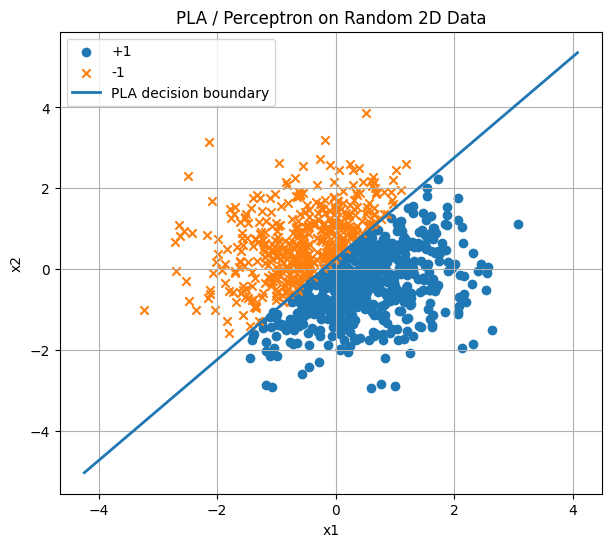

In [10]:
# Create a new figure window with a chosen size.
plt.figure(figsize=(7, 6))

# Plot points for class +1 as circles.
# X[y==1] selects only rows where y is +1.
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='o', label='+1')

# Plot points for class -1 as crosses.
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], marker='x', label='-1')

# Create x-values for drawing the decision boundary line across the plot range.
x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)

# If w2 is not zero, we can compute y using:
# w0 + w1*x + w2*y = 0  ->  y = -(w0 + w1*x)/w2
if abs(w_learned[2]) > 1e-8:
    y_vals = -(w_learned[0] + w_learned[1] * x_vals) / w_learned[2]
    plt.plot(x_vals, y_vals, linewidth=2, label='PLA decision boundary')
else:
    # If w2 is near zero, boundary becomes vertical:
    # w0 + w1*x = 0 -> x = -w0/w1
    x_vertical = -w_learned[0] / (w_learned[1] + 1e-12)
    plt.axvline(x_vertical, linewidth=2, label='PLA decision boundary (vertical)')

# Add a title to the graph.
plt.title("PLA / Perceptron on Random 2D Data")

# Label the x-axis and y-axis.
plt.xlabel("x1")
plt.ylabel("x2")

# Show a legend explaining markers/lines.
plt.legend()

# Add a grid to make it easier to read.
plt.grid(True)

# Display the final plot.
plt.show()